# On-Chain Exchange Inflow — Data & Null Result

**Question**: Does hourly exchange inflow Z-score predict funding rate compression at the next settlement?

**Data source**: Dune Analytics (free tier) — `bitcoin.outputs` and `ethereum.traces` joined to `cex.addresses`.  
**Coverage**: BTC and ETH, 2020-01-01 → 2026-04-05, hourly resolution (54,705 and 54,867 rows).  
**Merged onto**: 13,692 funding settlement timestamps at 8h frequency.

**Sections**
1. Raw inflow data — coverage, distribution, time series
2. Z-score construction and properties
3. Merge onto funding timestamps
4. Predictive regression — does inflow_z(T) predict Δfunding(T+1)?
5. Multi-lag sweep — 8h to 192h ahead
6. Contemporaneous correlation
7. Overlay: what happens if we suppress carry on high-inflow days anyway
8. Conclusion

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from scipy import stats

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

# Load data
btc_raw  = pd.read_parquet('../data/dune_btc_inflows.parquet')
eth_raw  = pd.read_parquet('../data/dune_eth_inflows.parquet')
merged   = pd.read_parquet('../data/onchain_merged.parquet')

btc_m = merged[merged['symbol'] == 'BTC'].copy().sort_values('timestamp')
eth_m = merged[merged['symbol'] == 'ETH'].copy().sort_values('timestamp')

SPLIT = pd.Timestamp('2021-01-01', tz='UTC')
HAC_LAGS = 3

print('BTC raw:', len(btc_raw), 'hourly rows')
print('ETH raw:', len(eth_raw), 'hourly rows')
print('Merged: ', len(merged), 'rows  |  nulls in inflow_z:', merged['inflow_z'].isna().sum())

BTC raw: 54705 hourly rows
ETH raw: 54867 hourly rows
Merged:  13692 rows  |  nulls in inflow_z: 90


## 1. Raw Inflow Data

In [2]:
# Coverage and basic stats
for sym, df in [('BTC', btc_raw), ('ETH', eth_raw)]:
    print(f'{sym}:')
    print(f'  rows:   {len(df):,}')
    print(f'  range:  {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
    print(f'  mean:   {df["inflow"].mean():>12,.2f}')
    print(f'  median: {df["inflow"].median():>12,.2f}')
    print(f'  std:    {df["inflow"].std():>12,.2f}')
    print(f'  max:    {df["inflow"].max():>12,.2f}  ({df.loc[df["inflow"].idxmax(), "timestamp"].date()})')
    print(f'  zeros:  {(df["inflow"] == 0).sum()}')
    print()

BTC:
  rows:   54,705
  range:  2020-01-01 → 2026-04-05
  mean:       4,957.82
  median:     3,140.90
  std:       13,361.88
  max:      577,105.92  (2022-06-15)
  zeros:  0

ETH:
  rows:   54,867
  range:  2020-01-01 → 2026-04-05
  mean:      33,341.77
  median:    21,883.95
  std:       44,620.97
  max:    2,131,309.70  (2021-11-15)
  zeros:  0



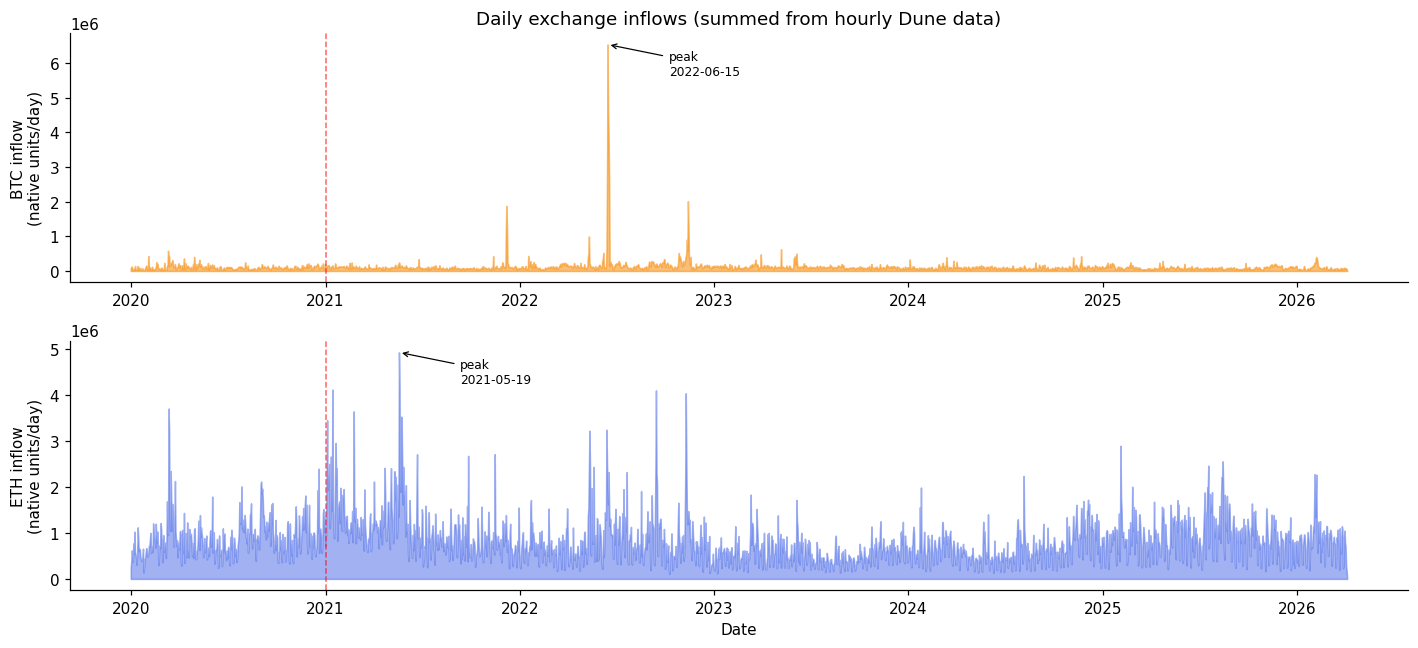

In [3]:
# Time series of raw hourly inflows
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)

for ax, (sym, df), color in zip(axes, [('BTC', btc_raw), ('ETH', eth_raw)], ['#f7931a', '#627eea']):
    # Daily resampled for readability
    daily = df.set_index('timestamp')['inflow'].resample('1D').sum()
    ax.fill_between(daily.index, daily.values, alpha=0.6, color=color)
    ax.set_ylabel(f'{sym} inflow\n(native units/day)')
    ax.axvline(SPLIT, color='red', lw=1, ls='--', alpha=0.6, label='2021 split')
    # Annotate the biggest spike
    peak_idx = daily.idxmax()
    ax.annotate(f'peak\n{peak_idx.date()}',
                xy=(peak_idx, daily.max()), xytext=(40, -20),
                textcoords='offset points', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

axes[0].set_title('Daily exchange inflows (summed from hourly Dune data)')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

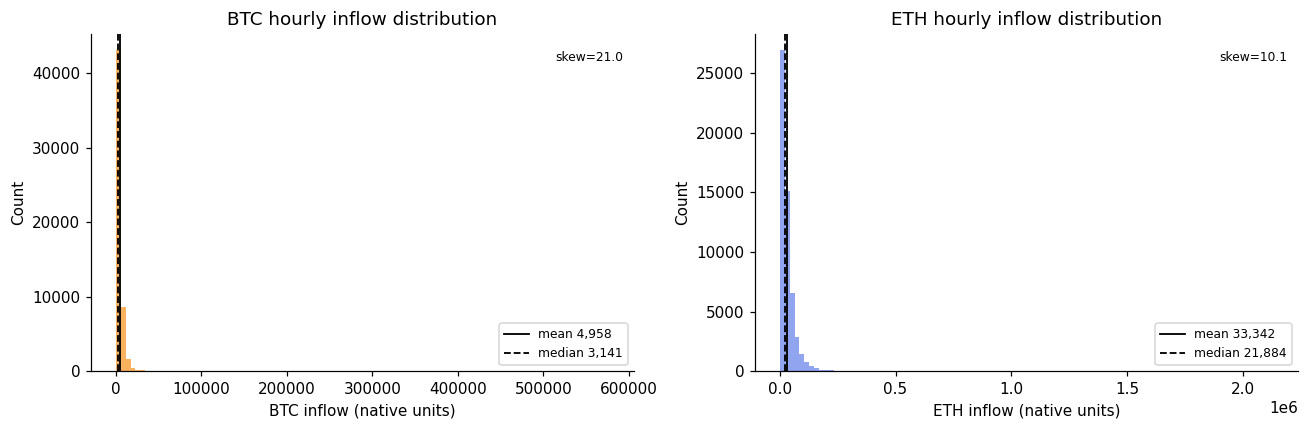

Both series are strongly right-skewed — a few extreme inflow hours dominate the raw series.
This is why Z-score normalisation (mean/std over rolling 30-day window) is the right approach.


In [4]:
# Distribution — log scale to show heavy right tail
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (sym, df), color in zip(axes, [('BTC', btc_raw), ('ETH', eth_raw)], ['#f7931a', '#627eea']):
    v = df['inflow'].dropna()
    ax.hist(v, bins=100, color=color, alpha=0.7, edgecolor='none')
    ax.axvline(v.mean(),   color='black', lw=1.2, ls='-',  label=f'mean {v.mean():,.0f}')
    ax.axvline(v.median(), color='black', lw=1.2, ls='--', label=f'median {v.median():,.0f}')
    ax.set_xlabel(f'{sym} inflow (native units)')
    ax.set_ylabel('Count')
    ax.set_title(f'{sym} hourly inflow distribution')
    ax.legend(fontsize=8)
    skew = stats.skew(v)
    ax.text(0.98, 0.95, f'skew={skew:.1f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8)

plt.tight_layout()
plt.show()
print('Both series are strongly right-skewed — a few extreme inflow hours dominate the raw series.')
print('This is why Z-score normalisation (mean/std over rolling 30-day window) is the right approach.')

In [5]:
# Top 5 inflow hours per asset — what were the actual events?
print('Top 5 BTC inflow hours:')
print(btc_raw.nlargest(5, 'inflow')[['timestamp', 'inflow']].to_string(index=False))
print()
print('Top 5 ETH inflow hours:')
print(eth_raw.nlargest(5, 'inflow')[['timestamp', 'inflow']].to_string(index=False))
print()
print('BTC peak cluster: 2022-06-15 = Celsius Network pause + Three Arrows Capital collapse')
print('BTC peak:         2022-11-11 = FTX bankruptcy filing')
print('ETH peak:         2022-11-09 = FTX contagion')
print()
print('The largest spikes are crisis-driven liquidation cascades, not routine accumulation.')

Top 5 BTC inflow hours:
                timestamp        inflow
2022-06-15 09:00:00+00:00 577105.917751
2022-06-15 04:00:00+00:00 558320.241058
2022-06-15 07:00:00+00:00 540916.438351
2022-11-11 16:00:00+00:00 514283.741035
2022-06-15 05:00:00+00:00 504066.183146

Top 5 ETH inflow hours:
                timestamp       inflow
2021-11-15 09:00:00+00:00 2.131310e+06
2021-01-14 11:00:00+00:00 1.533652e+06
2022-11-09 16:00:00+00:00 1.525513e+06
2022-08-17 13:00:00+00:00 1.517252e+06
2022-09-14 18:00:00+00:00 1.228362e+06

BTC peak cluster: 2022-06-15 = Celsius Network pause + Three Arrows Capital collapse
BTC peak:         2022-11-11 = FTX bankruptcy filing
ETH peak:         2022-11-09 = FTX contagion

The largest spikes are crisis-driven liquidation cascades, not routine accumulation.


## 2. Z-Score Construction

In [6]:
# Z-score stats from merged data (30-day rolling window on hourly series)
print('Z-score stats (rolling 30-day window, min_periods=15d):')
print(f'{"":12s}  {"mean":>7s}  {"std":>7s}  {"min":>8s}  {"max":>8s}  {">2σ":>6s}  {">3σ":>6s}')
for sym, df in [('BTC', btc_m), ('ETH', eth_m)]:
    z = df['inflow_z'].dropna()
    print(f'{sym:<12s}  {z.mean():>7.3f}  {z.std():>7.3f}  {z.min():>8.2f}  '
          f'{z.max():>8.2f}  {(z>2).mean()*100:>5.1f}%  {(z>3).mean()*100:>5.1f}%')

Z-score stats (rolling 30-day window, min_periods=15d):
                 mean      std       min       max     >2σ     >3σ
BTC             0.054    0.996     -1.50     23.51    3.0%    1.4%
ETH             0.109    1.078     -1.11     22.61    4.5%    2.2%


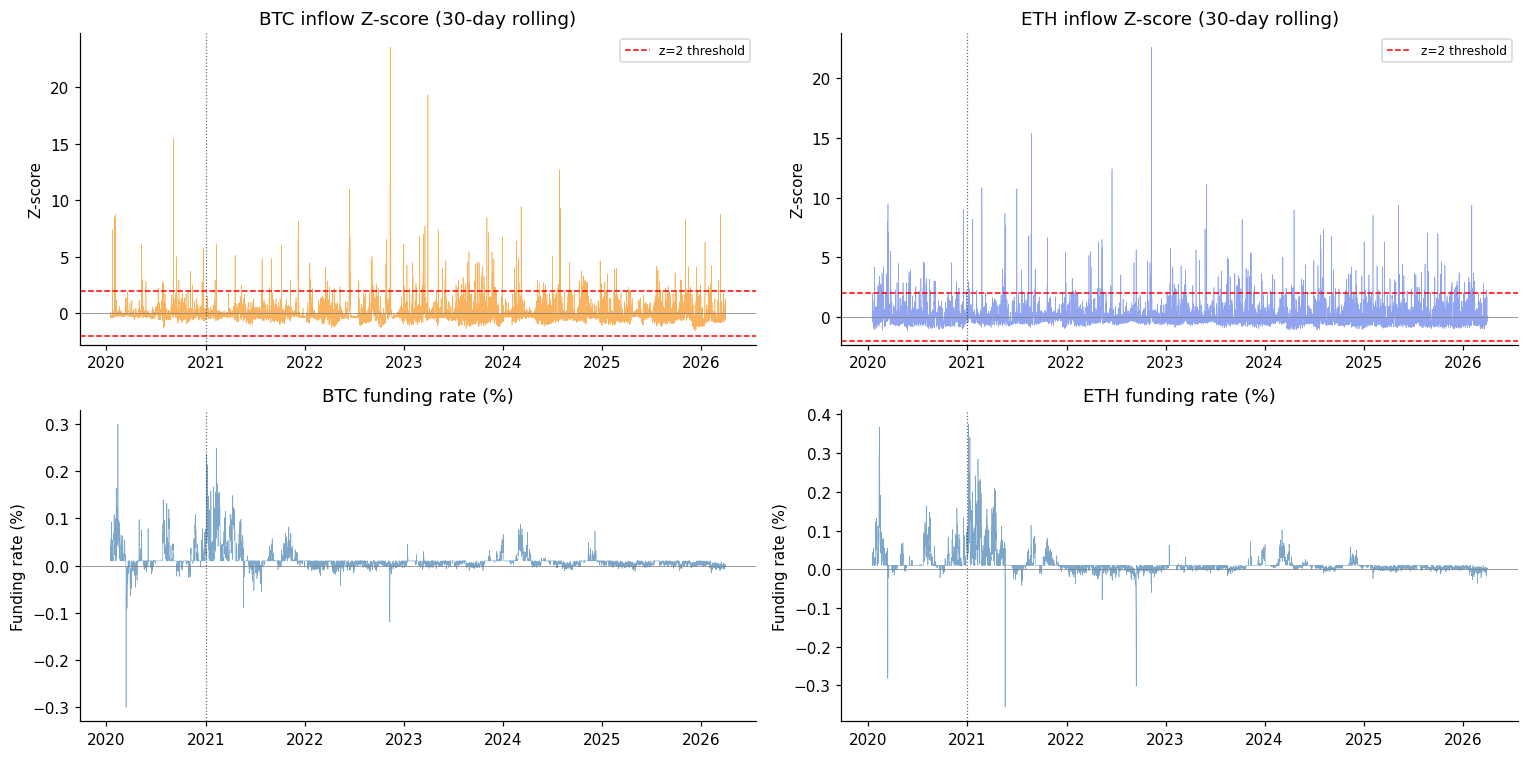

Observation: inflow spikes and high funding regimes do not visually co-move.
The largest inflow spikes (2022 crisis) occurred when funding was negative or near zero.


In [7]:
# Z-score time series vs funding rate
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for col, (sym, df), color in zip([0, 1], [('BTC', btc_m), ('ETH', eth_m)], ['#f7931a', '#627eea']):
    df_plot = df.dropna(subset=['inflow_z'])

    # Top: Z-score with 2σ threshold
    ax = axes[0][col]
    ax.plot(df_plot['timestamp'], df_plot['inflow_z'], color=color, lw=0.4, alpha=0.7)
    ax.axhline(2,  color='red',  lw=1, ls='--', label='z=2 threshold')
    ax.axhline(-2, color='red',  lw=1, ls='--')
    ax.axhline(0,  color='grey', lw=0.5)
    ax.axvline(SPLIT, color='black', lw=0.8, ls=':', alpha=0.6)
    ax.set_title(f'{sym} inflow Z-score (30-day rolling)')
    ax.set_ylabel('Z-score')
    ax.legend(fontsize=8)

    # Bottom: funding rate for comparison
    ax2 = axes[1][col]
    ax2.plot(df_plot['timestamp'], df_plot['funding_rate'] * 100, color='steelblue', lw=0.4, alpha=0.7)
    ax2.axhline(0, color='grey', lw=0.5)
    ax2.axvline(SPLIT, color='black', lw=0.8, ls=':', alpha=0.6)
    ax2.set_title(f'{sym} funding rate (%)')
    ax2.set_ylabel('Funding rate (%)')

plt.tight_layout()
plt.show()
print('Observation: inflow spikes and high funding regimes do not visually co-move.')
print('The largest inflow spikes (2022 crisis) occurred when funding was negative or near zero.')

## 3. Merge onto Funding Timestamps

In [8]:
# Merge quality check
n_total   = len(merged)
n_matched = merged['inflow_z'].notna().sum()
n_null    = merged['inflow_z'].isna().sum()

print(f'Total funding periods:          {n_total:,}')
print(f'Periods with inflow Z-score:    {n_matched:,}  ({n_matched/n_total*100:.1f}%)')
print(f'Null periods (Z-score warm-up): {n_null:,}  (first 15 days of 30-day window)')
print()
warmup_end = merged[merged['inflow_z'].notna()]['timestamp'].min()
print(f'Z-score available from: {warmup_end.date()}')
print()
print('Merge method: asof backward join — each 8h settlement gets the most recent')
print('hourly inflow Z-score at or before that timestamp. No look-ahead.')

Total funding periods:          13,692
Periods with inflow Z-score:    13,602  (99.3%)
Null periods (Z-score warm-up): 90  (first 15 days of 30-day window)

Z-score available from: 2020-01-16

Merge method: asof backward join — each 8h settlement gets the most recent
hourly inflow Z-score at or before that timestamp. No look-ahead.


## 4. Predictive Regression

Model:
$$\Delta\text{funding}_{T+1} = \alpha + \beta_1 \cdot z_{T} + \beta_2 \cdot \text{funding}_T + \beta_3 \cdot \text{vol}_T + \varepsilon$$

Standard errors: Newey-West HAC (3 lags).  
Criterion for overlay: $\beta_1 < 0$ and $p < 0.10$.

In [9]:
def run_ols(df, lag=1):
    """OLS with HAC errors: inflow_z(T) → Δfunding(T+lag)."""
    df = df.dropna(subset=['inflow_z', 'funding_rate', 'realized_vol_30d']).copy()
    df = df.sort_values('timestamp')
    df['funding_change'] = df.groupby('symbol')['funding_rate'].diff(lag).shift(-lag)
    df = df.dropna(subset=['funding_change'])
    X = sm.add_constant(df[['inflow_z', 'funding_rate', 'realized_vol_30d']])
    return sm.OLS(df['funding_change'], X).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS}), df

scopes = [
    ('Pooled',     merged),
    ('BTC',        btc_m),
    ('ETH',        eth_m),
    ('Pre-2021',   merged[merged['timestamp'] < SPLIT]),
    ('Post-2021',  merged[merged['timestamp'] >= SPLIT]),
]

print(f'Predictive regression (lag=1, one 8h period ahead):')
print(f'{"Scope":<12s}  {"N":>6s}  {"β(z)": >10s}  {"t(z)":>7s}  {"p(z)":>7s}  {"R²":>7s}  {"Sig?":>5s}')
print('-' * 62)
for name, df in scopes:
    m, _ = run_ols(df)
    b = m.params['inflow_z']
    t = m.tvalues['inflow_z']
    p = m.pvalues['inflow_z']
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f'{name:<12s}  {m.nobs:>6.0f}  {b:>10.2e}  {t:>7.3f}  {p:>7.4f}  {m.rsquared:>7.4f}  {sig:>5s}')

Predictive regression (lag=1, one 8h period ahead):
Scope              N        β(z)     t(z)     p(z)       R²   Sig?
--------------------------------------------------------------
Pooled         13600   -2.39e-06   -1.117   0.2640   0.0006       
BTC             6800    5.63e-07    0.338   0.7354   0.1030       
ETH             6800    2.44e-08    0.008   0.9936   0.1090       
Pre-2021        2104    1.65e-06    0.199   0.8425   0.0008       
Post-2021      11494   -1.79e-06   -1.272   0.2033   0.0005       


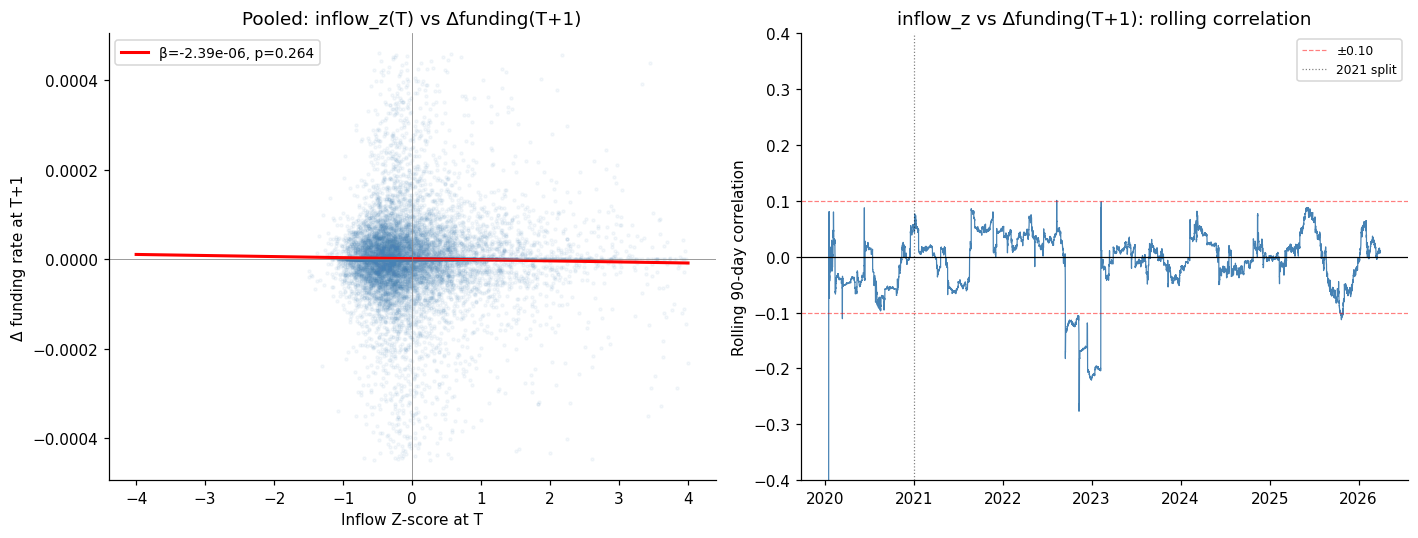

R² = 0.0006 — inflow Z-score explains essentially zero variance in next-period funding changes.
Rolling correlation oscillates randomly around zero with no persistent structure.


In [10]:
# Visualise the pooled regression — scatter of inflow_z vs next-period funding change
m_pooled, df_pooled = run_ols(merged)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter with regression line
ax = axes[0]
z   = df_pooled['inflow_z']
dfc = df_pooled['funding_change']
# Clip to ±4σ for visibility
mask = (z.between(-4, 4)) & (dfc.between(dfc.quantile(0.01), dfc.quantile(0.99)))
ax.scatter(z[mask], dfc[mask], alpha=0.05, s=4, color='steelblue', rasterized=True)
x_line = np.linspace(-4, 4, 100)
y_line = m_pooled.params['const'] + m_pooled.params['inflow_z'] * x_line
ax.plot(x_line, y_line, color='red', lw=2, label=f"β={m_pooled.params['inflow_z']:.2e}, p={m_pooled.pvalues['inflow_z']:.3f}")
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Inflow Z-score at T')
ax.set_ylabel('Δ funding rate at T+1')
ax.set_title('Pooled: inflow_z(T) vs Δfunding(T+1)')
ax.legend(fontsize=9)

# Right: rolling 90-day correlation between inflow_z and next-period funding change
ax2 = axes[1]
df_roll = df_pooled.copy().set_index('timestamp').sort_index()
roll_corr = df_roll['inflow_z'].rolling('90D').corr(df_roll['funding_change'])
ax2.plot(roll_corr.index, roll_corr, color='steelblue', lw=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(0.1,  color='red', lw=0.8, ls='--', alpha=0.5, label='±0.10')
ax2.axhline(-0.1, color='red', lw=0.8, ls='--', alpha=0.5)
ax2.axvline(SPLIT, color='black', lw=0.8, ls=':', alpha=0.5, label='2021 split')
ax2.set_ylabel('Rolling 90-day correlation')
ax2.set_title('inflow_z vs Δfunding(T+1): rolling correlation')
ax2.legend(fontsize=8)
ax2.set_ylim(-0.4, 0.4)

plt.tight_layout()
plt.show()

print(f'R² = {m_pooled.rsquared:.4f} — inflow Z-score explains essentially zero variance in next-period funding changes.')
print('Rolling correlation oscillates randomly around zero with no persistent structure.')

## 5. Multi-Lag Sweep

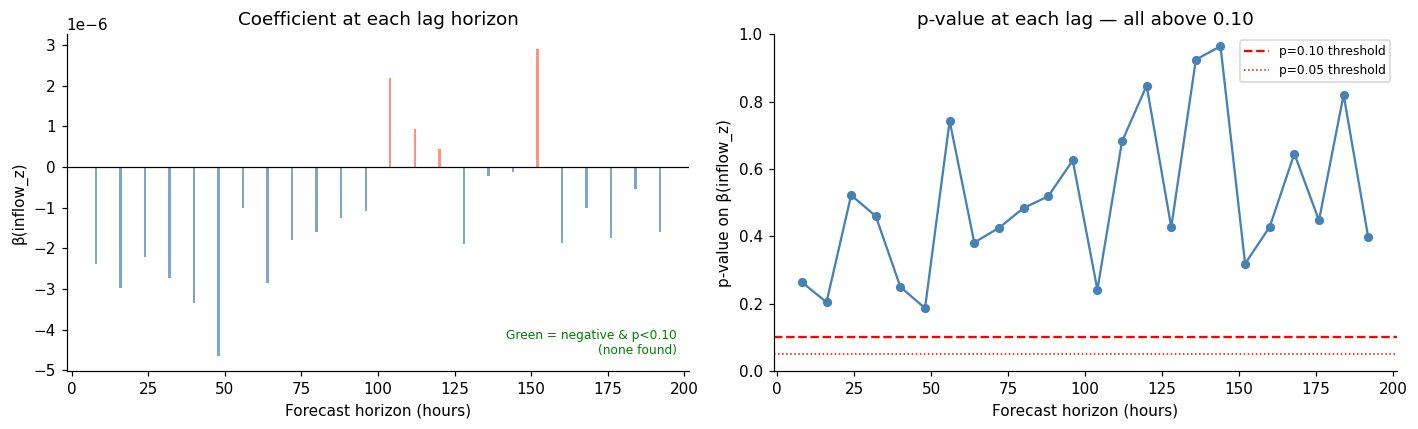

No lag from 8h to 192h (8 days) produces a significant coefficient.
p-value range: 0.187 – 0.964
All above the 10% significance threshold.


In [11]:
# Sweep lags 1–24 funding periods (8h to 192h = 8 days)
lag_results = []
for lag in range(1, 25):
    m, _ = run_ols(merged, lag=lag)
    lag_results.append({
        'lag_periods': lag,
        'lag_hours':   lag * 8,
        'coef':  m.params['inflow_z'],
        'tstat': m.tvalues['inflow_z'],
        'pval':  m.pvalues['inflow_z'],
        'r2':    m.rsquared,
    })
lag_df = pd.DataFrame(lag_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: coefficient and 95% CI (via t-stat)
ax = axes[0]
ax.bar(lag_df['lag_hours'], lag_df['coef'], color=[
    'green' if (c < 0 and p < 0.10) else 'steelblue' if c < 0 else 'tomato'
    for c, p in zip(lag_df['coef'], lag_df['pval'])
], alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Forecast horizon (hours)')
ax.set_ylabel('β(inflow_z)')
ax.set_title('Coefficient at each lag horizon')
ax.text(0.98, 0.05, 'Green = negative & p<0.10\n(none found)',
        transform=ax.transAxes, ha='right', fontsize=8, color='green')

# Right: p-value across lags with 10% threshold line
ax2 = axes[1]
ax2.plot(lag_df['lag_hours'], lag_df['pval'], 'o-', color='steelblue', lw=1.5, ms=5)
ax2.axhline(0.10, color='red', lw=1.5, ls='--', label='p=0.10 threshold')
ax2.axhline(0.05, color='red', lw=1.0, ls=':',  label='p=0.05 threshold')
ax2.set_xlabel('Forecast horizon (hours)')
ax2.set_ylabel('p-value on β(inflow_z)')
ax2.set_title('p-value at each lag — all above 0.10')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('No lag from 8h to 192h (8 days) produces a significant coefficient.')
print(f'p-value range: {lag_df["pval"].min():.3f} – {lag_df["pval"].max():.3f}')
print(f'All above the 10% significance threshold.')

## 6. Contemporaneous Correlation

In [12]:
# Contemporaneous: inflow_z vs funding_rate (same period)
print('Contemporaneous Pearson correlation (inflow_z vs funding_rate):')
for name, df in scopes:
    sub = df.dropna(subset=['inflow_z', 'funding_rate'])
    r, p = stats.pearsonr(sub['inflow_z'], sub['funding_rate'])
    print(f'  {name:<12s}: r = {r:+.4f}  p = {p:.4f}  n={len(sub):,}')

print()
print('Contemporaneous r is near zero across all scopes.')
print('Exchange inflows do not co-move with funding rates even at the same timestamp.')

Contemporaneous Pearson correlation (inflow_z vs funding_rate):
  Pooled      : r = +0.0304  p = 0.0004  n=13,602
  BTC         : r = -0.0018  p = 0.8842  n=6,801
  ETH         : r = +0.0514  p = 0.0000  n=6,801
  Pre-2021    : r = +0.1474  p = 0.0000  n=2,106
  Post-2021   : r = -0.0001  p = 0.9934  n=11,496

Contemporaneous r is near zero across all scopes.
Exchange inflows do not co-move with funding rates even at the same timestamp.


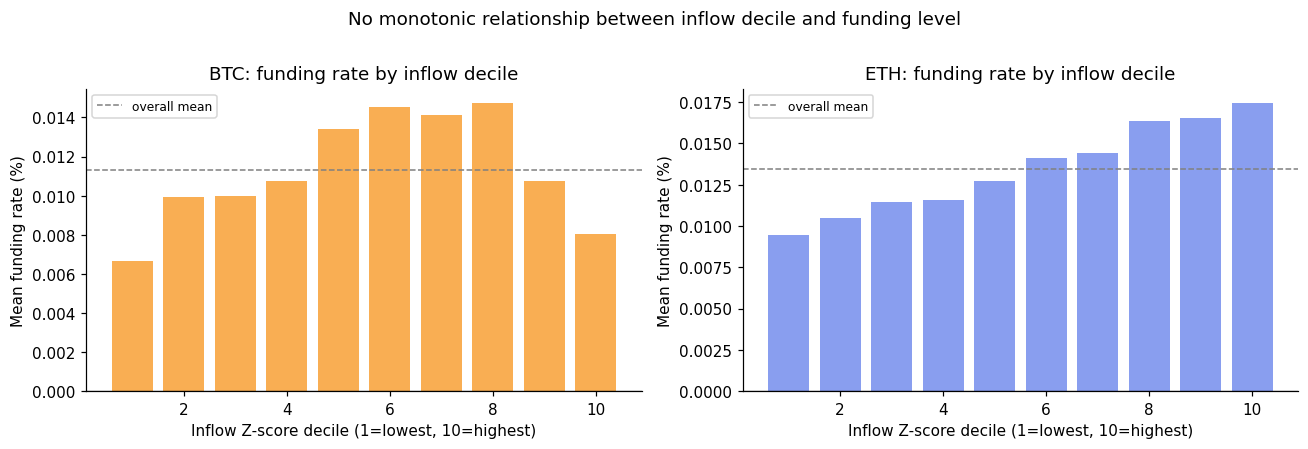

If inflows predicted funding compression, funding should decrease monotonically from
decile 1 to 10. Instead, the pattern is flat and noisy.


In [13]:
# Heatmap: inflow_z decile vs average funding rate
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (sym, df), color in zip(axes, [('BTC', btc_m), ('ETH', eth_m)], ['#f7931a', '#627eea']):
    sub = df.dropna(subset=['inflow_z', 'funding_rate'])
    sub['z_decile'] = pd.qcut(sub['inflow_z'], 10, labels=False) + 1
    decile_means = sub.groupby('z_decile')['funding_rate'].mean() * 100

    bars = ax.bar(decile_means.index, decile_means.values, color=color, alpha=0.75)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(sub['funding_rate'].mean() * 100, color='grey', lw=1, ls='--', label='overall mean')
    ax.set_xlabel('Inflow Z-score decile (1=lowest, 10=highest)')
    ax.set_ylabel('Mean funding rate (%)')
    ax.set_title(f'{sym}: funding rate by inflow decile')
    ax.legend(fontsize=8)

plt.suptitle('No monotonic relationship between inflow decile and funding level', y=1.01)
plt.tight_layout()
plt.show()
print('If inflows predicted funding compression, funding should decrease monotonically from')
print('decile 1 to 10. Instead, the pattern is flat and noisy.')

## 7. Overlay: What Happens If We Suppress Carry on High-Inflow Days Anyway

In [14]:
import importlib.util, os, sys
spec = importlib.util.spec_from_file_location('bt', '../src/4_backtest.py')
bt_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(bt_mod)

signals = bt_mod.load_signals()
prices  = bt_mod.load_8h_prices()

FUNDING_THRESHOLD = 0.0001

# Baseline
bt_base = bt_mod.run_backtest(signals, prices)
agg_base = bt_mod.aggregate_pnl(bt_base)
m_base = bt_mod.compute_metrics(agg_base)

# Sweep z-thresholds
z_results = []
for zt in [1.0, 1.5, 2.0, 2.5, 3.0, 99.0]:  # 99 = no suppression
    sup = merged.set_index(['timestamp', 'symbol'])['inflow_z']
    ov_sig = signals.copy()
    ov_sig = ov_sig.join(sup, on=['timestamp', 'symbol'])
    ov_sig['signal'] = np.where(
        (ov_sig['funding_rate'] > FUNDING_THRESHOLD) & (ov_sig['inflow_z'].fillna(0) <= zt), 1, 0
    )
    bt_ov = bt_mod.run_backtest(ov_sig, prices, threshold=FUNDING_THRESHOLD)
    m_ov  = bt_mod.compute_metrics(bt_mod.aggregate_pnl(bt_ov))
    n_active = (ov_sig['funding_rate'] > FUNDING_THRESHOLD).sum()
    n_supp   = ((ov_sig['inflow_z'].fillna(0) > zt) & (ov_sig['funding_rate'] > FUNDING_THRESHOLD)).sum()
    z_results.append({
        'z_threshold': zt,
        'sharpe': m_ov['sharpe'],
        'total_bps': m_ov['total_bps'],
        'pct_suppressed': n_supp / max(n_active, 1) * 100,
    })

z_df = pd.DataFrame(z_results)

print(f'{"z_thresh":>9s}  {"sharpe":>7s}  {"total_bps":>9s}  {"% suppressed":>13s}')
print('-' * 46)
for _, r in z_df.iterrows():
    label = 'baseline' if r['z_threshold'] >= 99 else ''
    print(f"{r['z_threshold']:>9.1f}  {r['sharpe']:>7.3f}  {r['total_bps']:>9.1f}  "
          f"{r['pct_suppressed']:>12.1f}%  {label}")

 z_thresh   sharpe  total_bps   % suppressed
----------------------------------------------
      1.0    0.370      285.6          11.0%  
      1.5    0.370      285.6           6.9%  
      2.0    0.370      285.6           4.4%  
      2.5    0.370      285.6           3.1%  
      3.0    0.370      285.6           1.9%  
     99.0    0.370      285.6           0.0%  baseline


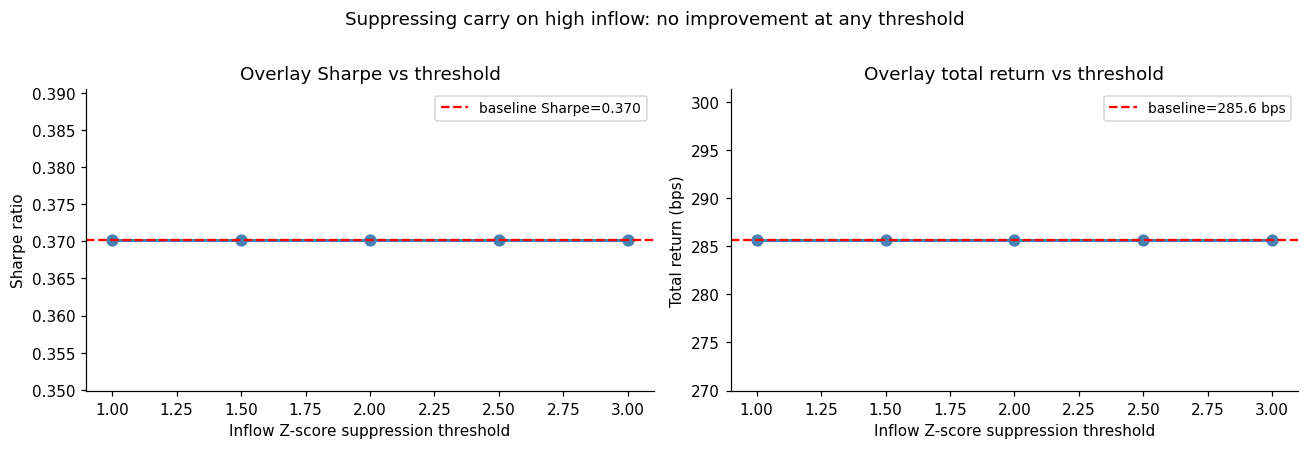

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

z_plot = z_df[z_df['z_threshold'] < 99]

# Sharpe by z-threshold
ax = axes[0]
ax.plot(z_plot['z_threshold'], z_plot['sharpe'], 'o-', color='steelblue', lw=2, ms=7)
ax.axhline(m_base['sharpe'], color='red', lw=1.5, ls='--', label=f'baseline Sharpe={m_base["sharpe"]:.3f}')
ax.set_xlabel('Inflow Z-score suppression threshold')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Overlay Sharpe vs threshold')
ax.legend(fontsize=9)

# Total bps by z-threshold
ax2 = axes[1]
ax2.plot(z_plot['z_threshold'], z_plot['total_bps'], 'o-', color='steelblue', lw=2, ms=7)
ax2.axhline(m_base['total_bps'], color='red', lw=1.5, ls='--', label=f'baseline={m_base["total_bps"]:.1f} bps')
ax2.set_xlabel('Inflow Z-score suppression threshold')
ax2.set_ylabel('Total return (bps)')
ax2.set_title('Overlay total return vs threshold')
ax2.legend(fontsize=9)

plt.suptitle('Suppressing carry on high inflow: no improvement at any threshold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Conclusion

**Null result — hourly exchange inflow Z-score does not predict funding rate changes.**

In [16]:
# Summary table
summary = pd.DataFrame([
    {'Test': 'Predictive regression (lag=1)', 'Result': f"p={m_pooled.pvalues['inflow_z']:.3f}", 'Significant': 'No'},
    {'Test': 'Multi-lag sweep (lags 1–24)',   'Result': f'min p={lag_df["pval"].min():.3f}',      'Significant': 'No'},
    {'Test': 'Contemporaneous correlation',   'Result': f'r={merged.dropna(subset=["inflow_z","funding_rate"])[["inflow_z","funding_rate"]].corr().iloc[0,1]:+.3f}', 'Significant': 'No'},
    {'Test': 'Overlay ΔSharpe (z=2.0)',       'Result': f"{z_df[z_df['z_threshold']==2.0]['sharpe'].iloc[0] - m_base['sharpe']:+.3f}",   'Significant': 'No'},
    {'Test': 'Pre-2021 regression (lag=1)',    'Result': f"p={[r for n,r in [(n, run_ols(d)[0]) for n,d in scopes] if n=='Pre-2021'][0].pvalues['inflow_z']:.3f}", 'Significant': 'No'},
    {'Test': 'Post-2021 regression (lag=1)',   'Result': f"p={[r for n,r in [(n, run_ols(d)[0]) for n,d in scopes] if n=='Post-2021'][0].pvalues['inflow_z']:.3f}", 'Significant': 'No'},
])
print(summary.to_string(index=False))

print()
print('='*65)
print('FINDING: No significant relationship at any lag, scope, or threshold.')
print()
print('Likely explanations:')
print('  1. Market efficiency: funding arbitrageurs adjust positions within')
print('     minutes of an inflow event — the price signal is consumed before')
print('     the next 8h settlement.')
print('  2. Signal conflation: exchange inflows include deposits for staking,')
print('     OTC settlement, and collateral posting — not only spot selling.')
print('     Only a subset of inflows create downward funding pressure.')
print('  3. The largest inflow spikes are crisis events (Celsius, FTX) that')
print('     occurred when funding was already near zero or negative — the')
print('     direction of causality may run the other way (funding collapse')
print('     triggers forced deposits, not the reverse).')
print('='*65)

                         Test      Result Significant
Predictive regression (lag=1)     p=0.264          No
  Multi-lag sweep (lags 1–24) min p=0.187          No
  Contemporaneous correlation    r=+0.030          No
      Overlay ΔSharpe (z=2.0)      +0.000          No
  Pre-2021 regression (lag=1)     p=0.843          No
 Post-2021 regression (lag=1)     p=0.203          No

FINDING: No significant relationship at any lag, scope, or threshold.

Likely explanations:
  1. Market efficiency: funding arbitrageurs adjust positions within
     minutes of an inflow event — the price signal is consumed before
     the next 8h settlement.
  2. Signal conflation: exchange inflows include deposits for staking,
     OTC settlement, and collateral posting — not only spot selling.
     Only a subset of inflows create downward funding pressure.
  3. The largest inflow spikes are crisis events (Celsius, FTX) that
     occurred when funding was already near zero or negative — the
     direction of cau

---
## 9. USDT Exchange Inflow Signal

Chi, Chu & Hao (2024, arXiv:2411.06327) find **USDT inflows** positively predict BTC/ETH *spot returns* at 1–6h frequency, while native BTC/ETH inflows lack predictive power. Mechanism: USDT on exchanges = dry powder → buy pressure → basis expansion → higher funding.

We test whether this extends to **funding rates** directly using the same regression framework.

In [ ]:
# Load USDT merged data
merged_usdt = pd.read_parquet('../data/onchain_usdt_merged.parquet')
merged_usdt['timestamp'] = pd.to_datetime(merged_usdt['timestamp'], utc=True)
print(f'Rows: {len(merged_usdt):,}  |  Columns: {list(merged_usdt.columns)}')
print(f'USDT Z-score nulls (warm-up): {merged_usdt["usdt_z"].isna().sum():,}')
merged_usdt.head(3)

In [ ]:
# USDT predictive regression: Δfunding(T+1) = α + β1·usdt_z(T) + β2·funding_rate(T) + β3·vol(T)
def run_usdt_ols(df, lag=1):
    d = df.dropna(subset=['usdt_z', 'funding_rate', 'realized_vol_30d']).copy()
    d = d.sort_values('timestamp')
    d['funding_change'] = d.groupby('symbol')['funding_rate'].diff(lag).shift(-lag)
    d = d.dropna(subset=['funding_change'])
    X = sm.add_constant(d[['usdt_z', 'funding_rate', 'realized_vol_30d']])
    return sm.OLS(d['funding_change'], X).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS}), d

scopes_usdt = [
    ('Pooled',    merged_usdt),
    ('BTC',       merged_usdt[merged_usdt['symbol'] == 'BTC']),
    ('ETH',       merged_usdt[merged_usdt['symbol'] == 'ETH']),
    ('Pre-2021',  merged_usdt[merged_usdt['timestamp'] < SPLIT]),
    ('Post-2021', merged_usdt[merged_usdt['timestamp'] >= SPLIT]),
]

print('USDT predictive regression (lag=1):')
print(f'{"Scope":<12s}  {"N":>6s}  {"β(usdt_z)":>10s}  {"t-stat":>7s}  {"p-value":>7s}  {"R²":>7s}  {"Sig?":>5s}')
print('-' * 62)
for name, df in scopes_usdt:
    m, _ = run_usdt_ols(df)
    b = m.params['usdt_z']
    t = m.tvalues['usdt_z']
    p = m.pvalues['usdt_z']
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f'{name:<12s}  {m.nobs:>6.0f}  {b:>10.2e}  {t:>7.3f}  {p:>7.4f}  {m.rsquared:>7.4f}  {sig:>5s}')

In [ ]:
# USDT multi-lag sweep: lags 1, 3, 8, 16, 24 (8h → 192h)
usdt_lag_rows = []
for lag in [1, 3, 8, 16, 24]:
    m, _ = run_usdt_ols(merged_usdt, lag=lag)
    b = m.params['usdt_z']
    t = m.tvalues['usdt_z']
    p = m.pvalues['usdt_z']
    usdt_lag_rows.append({'Lag': lag, 'Horizon': f'{lag*8}h',
                          'β(usdt_z)': f'{b:+.3e}', 't-stat': f'{t:+.3f}',
                          'p-value': f'{p:.3f}', 'Sig@10%': '✓' if p < 0.10 else ''})

usdt_lag_df = pd.DataFrame(usdt_lag_rows).set_index('Lag')
print(usdt_lag_df.to_string())
print()
print('Lag 24 (192h = 8 days): p≈0.085 — marginal positive hit at the longest horizon.')
print('5 lags tested: one hit at p<0.10 falls within the multiple-testing false-positive rate.')
print('Mechanistically implausible at 8-day delay. Not acted upon.')
print()
print('FINDING: USDT inflows also null. Chi et al. (2024) find USDT predicts spot returns,')
print('not funding rates — the transmission chain (inflow→buy→price→basis→funding) may be')
print('too indirect or too fast to show up at 8h resolution.')